# CIFAR Image Classification using CNN (100 Classes)

In [39]:
# Importing the libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import pickle
from keras.models import Sequential
from keras.layers import Conv2D, Dense, MaxPool2D, BatchNormalization, Flatten, Dropout, Input, RandomFlip, RandomRotation, RandomZoom, Input, GlobalAveragePooling2D
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import accuracy_score
from joblib import dump, load

### Data Preprocessing

In [2]:
file_path = '../data/cifar-100-python'

# Unpickling the data
def unpickle(file):
    with open(file, 'rb') as fo:
        dict_val = pickle.load(fo, encoding='bytes')
    return dict_val

# Load the train and test set
train_dict = unpickle(os.path.join(file_path, 'train'))
test_dict = unpickle(os.path.join(file_path, 'test'))

X_train, y_train = train_dict[b'data'], train_dict[b'fine_labels']
X_test, y_test = test_dict[b'data'], test_dict[b'fine_labels']

# Reshaping X_train and Xtest from (len, 3072) to (len, 32, 32, 3)
X_train = X_train.reshape(len(X_train), 3, 32, 32).transpose(0, 2, 3, 1)
X_test = X_test.reshape(len(X_test), 3, 32, 32).transpose(0, 2, 3, 1)

# Getting the label names
meta_dict = unpickle(os.path.join(file_path, 'meta'))
class_names = [item.decode('utf-8') for item in meta_dict[b'fine_label_names']]

# Convert y_train and y_test into an array
y_train, y_test = np.array(y_train), np.array(y_test)

print(f'Training data shape: {X_train.shape}')
print(f'Training label shape: {y_train.shape}')
print(f'Test data shape: {X_test.shape}')
print(f'Test label shape: {y_test.shape}')
print(f'Class names: {class_names}')

Training data shape: (50000, 32, 32, 3)
Training label shape: (50000,)
Test data shape: (10000, 32, 32, 3)
Test label shape: (10000,)
Class names: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'swee

#### Normalizing the data

In [3]:
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

In [4]:
X_train

array([[[[1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         ...,
         [0.7647059 , 0.8039216 , 0.75686276],
         [0.83137256, 0.8784314 , 0.8       ],
         [0.7137255 , 0.7607843 , 0.654902  ]],

        [[1.        , 1.        , 1.        ],
         [0.99607843, 0.99607843, 0.99607843],
         [0.99607843, 0.99607843, 0.99607843],
         ...,
         [0.6666667 , 0.6901961 , 0.5882353 ],
         [0.6313726 , 0.65882355, 0.50980395],
         [0.57254905, 0.6039216 , 0.44313726]],

        [[1.        , 1.        , 1.        ],
         [0.99607843, 0.99607843, 0.99607843],
         [1.        , 1.        , 1.        ],
         ...,
         [0.7411765 , 0.78039217, 0.6627451 ],
         [0.6509804 , 0.69803923, 0.50980395],
         [0.4745098 , 0.52156866, 0.34117648]],

        ...,

        [[0.5803922 , 0.7254902 , 0.30980393],
         [0.5568628 , 0.7137255 , 0.22352941]

In [5]:
X_test

array([[[[0.78039217, 0.84313726, 0.9764706 ],
         [0.76862746, 0.827451  , 0.95686275],
         [0.7647059 , 0.8235294 , 0.9529412 ],
         ...,
         [0.84705883, 0.90588236, 0.98039216],
         [0.8509804 , 0.90588236, 0.98039216],
         [0.8784314 , 0.91764706, 0.9882353 ]],

        [[0.77254903, 0.8235294 , 0.9372549 ],
         [0.7647059 , 0.8156863 , 0.93333334],
         [0.7647059 , 0.8235294 , 0.9411765 ],
         ...,
         [0.90588236, 0.9529412 , 0.98039216],
         [0.9137255 , 0.9529412 , 0.98039216],
         [0.94509804, 0.9607843 , 0.99215686]],

        [[0.87058824, 0.8862745 , 0.9647059 ],
         [0.8352941 , 0.8627451 , 0.9490196 ],
         [0.81960785, 0.85882354, 0.9529412 ],
         ...,
         [0.9529412 , 0.98039216, 0.9843137 ],
         [0.95686275, 0.9764706 , 0.9843137 ],
         [0.98039216, 0.98039216, 0.99215686]],

        ...,

        [[0.28235295, 0.28627452, 0.3882353 ],
         [0.2784314 , 0.2901961 , 0.4       ]

## Building the CNN Model
In order to avoid overfitting, we will implement some precautions and give certain instructions to the model such as Data Augmentation, Batch Normalization and model calllbacks.

In [6]:
cnn = Sequential()

# Defining the input shape
cnn.add(Input(shape=(32, 32, 3)))

# Adding Data Augmentation
cnn.add(RandomFlip("horizontal"))
cnn.add(RandomRotation(0.05))
cnn.add(RandomZoom(0.1))

### Building the Convolutional layers

In [7]:
# Block 1
cnn.add(Conv2D(filters = 32, kernel_size = 3, padding = 'same', activation = 'relu'))
cnn.add(BatchNormalization())
cnn.add(Conv2D(filters = 32, kernel_size = 3, padding = 'same', activation = 'relu'))
cnn.add(BatchNormalization())
cnn.add(MaxPool2D(pool_size = 2, strides = 2))

# Block 2
cnn.add(Conv2D(filters = 64, kernel_size = 3, padding = 'same', activation = 'relu'))
cnn.add(BatchNormalization())
cnn.add(Conv2D(filters = 64, kernel_size = 3, padding = 'same', activation = 'relu'))
cnn.add(BatchNormalization())
cnn.add(MaxPool2D(pool_size = 2, strides = 2))

# Block 3
cnn.add(Conv2D(filters = 128, kernel_size = 3, padding = 'same', activation = 'relu'))
cnn.add(BatchNormalization())
cnn.add(Conv2D(filters = 128, kernel_size = 3, padding = 'same', activation = 'relu'))
cnn.add(BatchNormalization())
cnn.add(MaxPool2D(pool_size = 2, strides = 2))

# Block 4
cnn.add(Conv2D(filters = 256, kernel_size = 3, padding = 'same', activation = 'relu'))
cnn.add(BatchNormalization())
cnn.add(Conv2D(filters = 256, kernel_size = 3, padding = 'same', activation = 'relu'))
cnn.add(BatchNormalization())
cnn.add(MaxPool2D(pool_size = 2, strides = 2))

# cnn.add(Flatten())
cnn.add(GlobalAveragePooling2D())

# Compile the model
cnn.add(Dense(units = 256, activation = 'relu'))

# Dropout layer
cnn.add(Dropout(0.5))

# Output layer
cnn.add(Dense(units = 100, activation = 'softmax'))

# opt = tf.keras.optimizers.RMSprop(learning_rate=0.0001)
optimizer = tf.keras.optimizers.AdamW(learning_rate=0.0001, weight_decay=1e-4)
cnn.compile(optimizer = optimizer, loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])

cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation (RandomRotation)     │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom (RandomZoom)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 1,267,588 (4.84 MB)

 Trainable params: 1,265,668 (4.83 MB)

 Non-trainable params: 1,920 (7.50 KB)

### Setting up callbacks and training the model

In [8]:
callbacks = [
    EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True),
    ReduceLROnPlateau(monitor = 'val_loss', factor = 0.3, patience = 5, min_lr = 1e-6)
]

history = cnn.fit(X_train, y_train,
                  validation_data = (X_test, y_test),
                  epochs = 60,
                  batch_size = 64,
                  callbacks = callbacks,
                  shuffle = True)

Epoch 1/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 71ms/step - accuracy: 0.0770 - loss: 4.2223 - val_accuracy: 0.1536 - val_loss: 3.6966 - learning_rate: 1.0000e-04
Epoch 2/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 74ms/step - accuracy: 0.1422 - loss: 3.7221 - val_accuracy: 0.1922 - val_loss: 3.4155 - learning_rate: 1.0000e-04
Epoch 3/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step - accuracy: 0.1868 - loss: 3.4486 - val_accuracy: 0.2286 - val_loss: 3.2212 - learning_rate: 1.0000e-04
Epoch 4/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 60s 76ms/step - accuracy: 0.2266 - loss: 3.2319 - val_accuracy: 0.2670 - val_loss: 3.0020 - learning_rate: 1.0000e-04
Epoch 5/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 76ms/step - accuracy: 0.2510 - loss: 3.0733 - val_accuracy: 0.3013 - val_loss: 2.8338 - learning_rate: 1.0000e-04
Epoch 6/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 76ms/step - accuracy: 0.2792 - loss: 2.9223 - val_accuracy: 0.3136 - val_loss: 2.7636 - learning_rate: 1.0000e-04
Epoch 7/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 76ms/ste

In [41]:
dump(cnn, '../models/cnn_image_classification_100_model.joblib')

['../models/cnn_image_classification_100_model.joblib']

In [10]:
# model = load('../models/cnn_image_classification_100_model')

## Analysis After Modelling

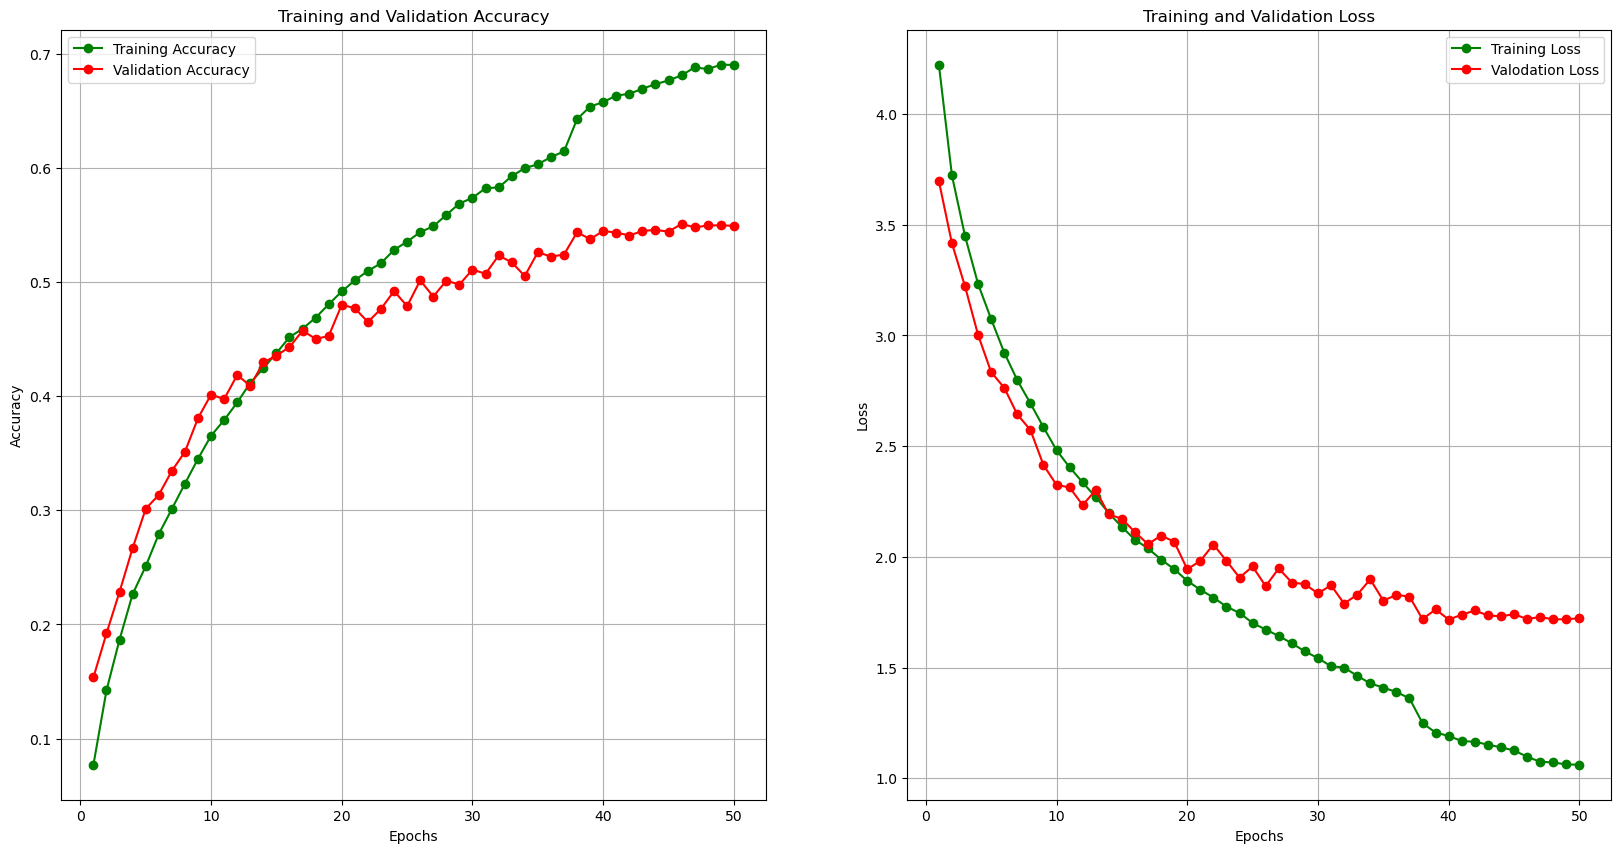

In [13]:
epochs = [i for i in range(1, 51)]
fig, ax = plt.subplots(1, 2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
fig.set_size_inches(20, 10)

ax[0].plot(epochs, train_acc, 'go-', label = 'Training Accuracy')
ax[0].plot(epochs, val_acc, 'ro-', label = 'Validation Accuracy')
ax[0].set_title('Training and Validation Accuracy')
ax[0].legend()
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].grid()

ax[1].plot(epochs, train_loss, 'go-', label = 'Training Loss')
ax[1].plot(epochs, val_loss, 'ro-', label = 'Valodation Loss')
ax[1].set_title('Training and Validation Loss')
ax[1].legend()
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].grid()
plt.savefig('../plots/Accuracy and Loss per Epochs Chart')
plt.show()

In [27]:
predictions = cnn.predict(X_test)
y_pred = np.argmax(predictions, axis=1)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


array([12, 33,  4, ..., 51, 42, 92], shape=(10000,))

In [17]:
y_test

array([49, 33, 72, ..., 51, 42, 70], shape=(10000,))

In [31]:
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

Final Test Accuracy: 54.48%


In [32]:
top5_metric = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5)
top5_metric.update_state(y_test, predictions)
print(f"Top-5 Accuracy: {top5_metric.result().numpy() * 100:.2f}%")

Top-5 Accuracy: 82.34%
